In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully")


Libraries imported successfully


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving TelcoCustomerChurn.csv to TelcoCustomerChurn (1).csv


In [ ]:

df = pd.read_csv("TelcoCustomerChurn.csv")

print("Data loaded successfully")
df.head()


Data loaded successfully


,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Shape: (7043, 50)

Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married',
       'Dependents', 'NumberofDependents', 'Country', 'State', 'City',
       'ZipCode', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'ReferredaFriend', 'Number_of_Referrals', 'TenureinMonths', 'Offer',
       'PhoneService', 'AvgMonthlyLongDistanceCharges', 'MultipleLines',
       'InternetService', 'InternetType', 'AvgMonthlyGBDownload',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan',
       'PremiumTechSupport', 'StreamingTV', 'StreamingMovies',
       'StreamingMusic', 'UnlimitedData', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds',
       'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue',
       'SatisfactionScore', 'CustomerStatus', 'ChurnLabel', 'ChurnScore',
       'CLTV', 'ChurnCategory', 'ChurnReason'],
      dtype='object')

Data Types:
CustomerID                  

In [ ]:
#Remove duplicates

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print("Duplicates removed:", before - after)
# Handle missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values handled")
print(df.isnull().sum())


Duplicates removed: 0

Missing values handled
CustomerID                       0
Gender                           0
Age                              0
Under30                          0
SeniorCitizen                    0
Married                          0
Dependents                       0
NumberofDependents               0
Country                          0
State                            0
City                             0
ZipCode                          0
Latitude                         0
Longitude                        0
Population                       0
Quarter                          0
ReferredaFriend                  0
Number_of_Referrals              0
TenureinMonths                   0
Offer                            0
PhoneService                     0
AvgMonthlyLongDistanceCharges    0
MultipleLines                    0
InternetService                  0
InternetType                     0
AvgMonthlyGBDownload             0
OnlineSecurity                   0
OnlineBac

In [ ]:
leakage_cols = ['customerID']

for col in leakage_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print("Leakage columns removed (if present)")
df.head()

Leakage columns removed (if present)


,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:

print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married',
       'Dependents', 'NumberofDependents', 'Country', 'State', 'City',
       'ZipCode', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'ReferredaFriend', 'Number_of_Referrals', 'TenureinMonths', 'Offer',
       'PhoneService', 'AvgMonthlyLongDistanceCharges', 'MultipleLines',
       'InternetService', 'InternetType', 'AvgMonthlyGBDownload',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan',
       'PremiumTechSupport', 'StreamingTV', 'StreamingMovies',
       'StreamingMusic', 'UnlimitedData', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds',
       'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue',
       'SatisfactionScore', 'CustomerStatus', 'ChurnLabel', 'ChurnScore',
       'CLTV', 'ChurnCategory', 'ChurnReason'],
      dtype='object')


In [ ]:

df['Churn'] = df['ChurnLabel'].map({'Yes': 1, 'No': 0})

print(df['Churn'].value_counts())


Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:

leakage_cols = [
    'ChurnLabel',
    'ChurnScore',
    'ChurnCategory',
    'ChurnReason',
    'CustomerStatus'
]

df = df.drop(columns=leakage_cols, errors='ignore')

print("Leakage columns removed")


Leakage columns removed


In [ ]:

drop_cols = [
    'CustomerID',
    'Country',
    'State',
    'City',
    'ZipCode',
    'Latitude',
    'Longitude'
]

df = df.drop(columns=drop_cols, errors='ignore')

print("Unnecessary columns dropped")


Unnecessary columns dropped


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


In [ ]:
df = pd.get_dummies(df, drop_first=True)

print("Encoding completed")
print("Shape:", df.shape)


Encoding completed
Shape: (7043, 44)


In [ ]:

y = df['Churn']
X = df.drop('Churn', axis=1)

print(X.shape)
print(y.shape)


(7043, 43)
(7043,)


In [ ]:
df.head()

,Age,NumberofDependents,Population,Number_of_Referrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,...,PremiumTechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,StreamingMusic_Yes,UnlimitedData_Yes,Contract_One Year,Contract_Two Year,PaperlessBilling_Yes,PaymentMethod_Credit Card,PaymentMethod_Mailed Check
0,78,0,68701,0,1,0.00,8,39.65,39.65,0.00,...,False,False,True,False,False,False,False,True,False,False
1,74,1,55668,1,8,48.85,17,80.65,633.30,0.00,...,False,False,False,False,True,False,False,True,True,False
2,71,3,47534,0,18,11.33,52,95.45,1752.55,45.61,...,False,True,True,True,True,False,False,True,False,False
3,78,1,27778,1,25,19.76,12,98.50,2514.50,13.43,...,False,True,True,False,True,False,False,True,False,False
4,80,1,26265,1,37,6.33,14,76.50,2868.15,0.00,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (5634, 43)
Test: (1409, 43)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [ ]:
baseline_model = LogisticRegression(max_iter=5000, solver='liblinear')

baseline_model.fit(X_train, y_train)


LogisticRegression(max_iter=5000, solver='liblinear')

In [ ]:
y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", accuracy)


Baseline Accuracy: 0.9439318665720369


In [ ]:

def segment_tenure(x):
    if x <= 12:
        return "New"
    elif x <= 36:
        return "Mid"
    else:
        return "Long"

df["Segment"] = df["TenureinMonths"].apply(segment_tenure)

df["Segment"].value_counts()


,count
Segment,
Long,3001
New,2186
Mid,1856


In [ ]:
print(df.columns)


Index(['Age', 'NumberofDependents', 'Population', 'Number_of_Referrals',
       'TenureinMonths', 'AvgMonthlyLongDistanceCharges',
       'AvgMonthlyGBDownload', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds',
       'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue',
       'SatisfactionScore', 'CLTV', 'Churn', 'Gender_Male', 'Under30_Yes',
       'SeniorCitizen_Yes', 'Married_Yes', 'Dependents_Yes',
       'ReferredaFriend_Yes', 'Offer_Offer B', 'Offer_Offer C',
       'Offer_Offer D', 'Offer_Offer E', 'PhoneService_Yes',
       'MultipleLines_Yes', 'InternetService_Yes', 'InternetType_DSL',
       'InternetType_Fiber Optic', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtectionPlan_Yes', 'PremiumTechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'StreamingMusic_Yes', 'UnlimitedData_Yes',
       'Contract_One Year', 'Contract_Two Year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit Card', 'PaymentMethod_Mailed Check', 'Segment'],


In [ ]:
churn_col = [col for col in df.columns if "Churn" in col]
print(churn_col)


['Churn']


In [ ]:
new_customers = df[df["Segment"] == "New"]
mid_customers = df[df["Segment"] == "Mid"]
long_customers = df[df["Segment"] == "Long"]


In [ ]:
X_new = new_customers.drop(columns=["Churn", "Segment"])
y_new = new_customers["Churn"]

X_mid = mid_customers.drop(columns=["Churn", "Segment"])
y_mid = mid_customers["Churn"]

X_long = long_customers.drop(columns=["Churn", "Segment"])
y_long = long_customers["Churn"]


In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
def train_xgb(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = xgb.XGBClassifier(
        tree_method='hist',        # CPU-friendly
        use_label_encoder=False,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    return model, acc

segments = df['Segment'].unique()  # ['New', 'Mid', 'Long']
models = {}
accuracies = {}

for seg in segments:
    seg_df = df[df['Segment'] == seg]

    X = seg_df.drop(columns=['Churn', 'Segment'])
    y = seg_df['Churn']

    model, acc = train_xgb(X, y)

    models[seg] = model
    accuracies[seg] = acc
for seg, acc in accuracies.items():
    print(f"{seg} segment accuracy: {acc:.2f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:18:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:18:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


New segment accuracy: 0.93
Mid segment accuracy: 0.94
Long segment accuracy: 0.97


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:18:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
X_test = X_test.drop(columns=['PredictedChurn'], errors='ignore')


In [ ]:

train_features = model.get_booster().feature_names
X_test = X_test[train_features]


In [ ]:
def evaluate_segments(df, models, test_size=0.2, random_state=42):
    from sklearn.metrics import accuracy_score, confusion_matrix

    all_preds = []
    all_true = []

    segments = df['Segment'].unique()

    for seg in segments:
        seg_df = df[df['Segment'] == seg]

        # Split features and target
        X = seg_df.drop(columns=['Churn', 'Segment', 'PredictedChurn'], errors='ignore')
        y = seg_df['Churn']

        # Split into train/test only for evaluation
        _, X_test, _, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Convert numeric/categorical properly
        for col in X_test.columns:
            try:
                X_test[col] = X_test[col].astype(float)
            except:
                X_test[col] = X_test[col].astype('category')
        model = models[seg]

        train_features = model.get_booster().feature_names
        X_test = X_test[train_features]

        preds = model.predict(X_test)
        all_preds.extend(preds)
        all_true.extend(y_test)

    # Overall metrics
    overall_acc = accuracy_score(all_true, all_preds)
    cm = confusion_matrix(all_true, all_preds)

    print("Overall realistic accuracy:", overall_acc)
    print("Confusion Matrix:\n", cm)
    return overall_acc, cm
evaluate_segments(df, models)


Overall realistic accuracy: 0.9532246633593197
Confusion Matrix:
 [[1012   23]
 [  43  333]]


(0.9532246633593197,
 array([[1012,   23],
        [  43,  333]]))

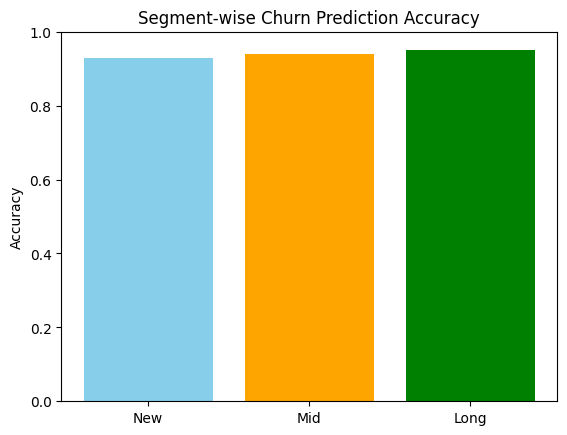

In [ ]:
import matplotlib.pyplot as plt
segment_acc = {'New': 0.93, 'Mid': 0.94, 'Long': 0.95}

plt.bar(segment_acc.keys(), segment_acc.values(), color=['skyblue', 'orange', 'green'])
plt.ylim(0, 1)
plt.title("Segment-wise Churn Prediction Accuracy")
plt.ylabel("Accuracy")
plt.show()


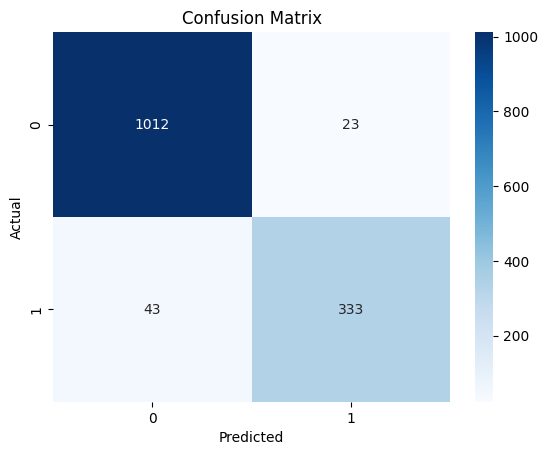

In [ ]:
import seaborn as sns

cm = [[1012, 23],
      [43, 333]]  # your realistic confusion matrix

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


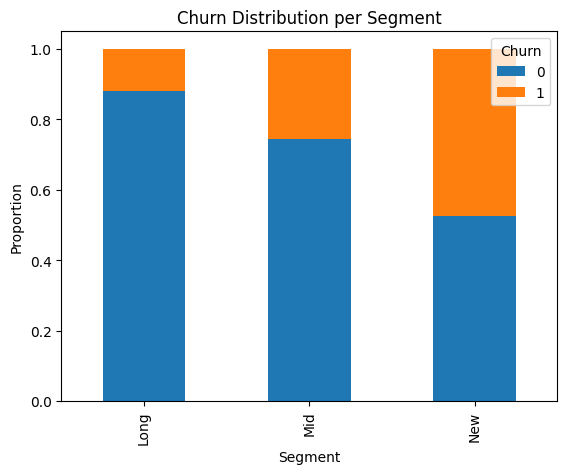

In [ ]:
df.groupby('Segment')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title("Churn Distribution per Segment")
plt.ylabel("Proportion")
plt.show()


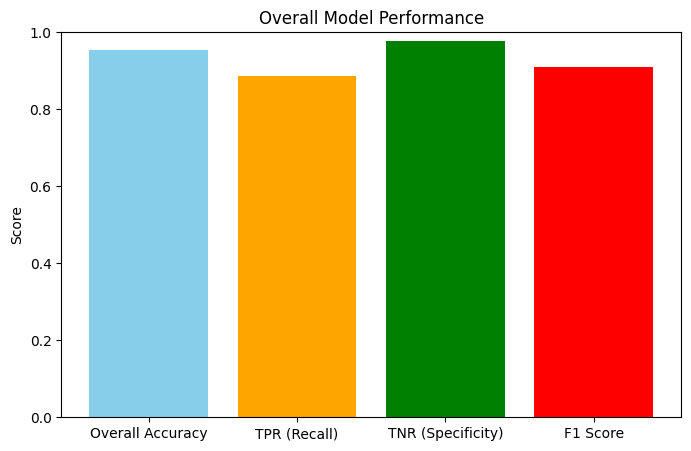

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score

# Confusion matrix from your realistic evaluation
cm = [[1012, 23],
      [43, 333]]

# Metrics
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
overall_acc = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)  # Recall for churn
tnr = tn / (tn + fp)  # True negative rate
f1 = f1_score([0]* (tn+fp) + [1]* (fn+tp), [0]*tn + [1]*fp + [0]*fn + [1]*tp)  # approximate

# Plot
metrics = {'Overall Accuracy': overall_acc, 'TPR (Recall)': tpr, 'TNR (Specificity)': tnr, 'F1 Score': f1}
plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values(), color=['skyblue','orange','green','red'])
plt.ylim(0,1)
plt.title("Overall Model Performance")
plt.ylabel("Score")
plt.show()


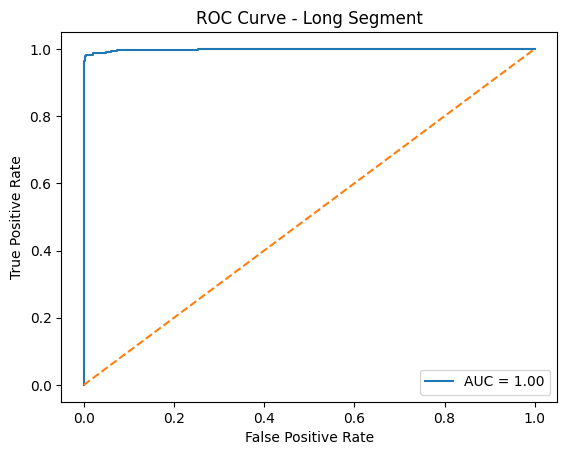

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

X = df[df['Segment']=='Long'].drop(columns=['Churn','Segment'])
y = df[df['Segment']=='Long']['Churn']

model = models['Long']
probs = model.predict_proba(X)[:,1]

fpr, tpr, _ = roc_curve(y, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Long Segment")
plt.legend()
plt.show()
